# SeaAlert - Statistical Validation and Performance Metrics

This notebook addresses reviewer concerns regarding statistical reliability, calibration, and real-time feasibility.

**Table II** - Classification performance on clean data (Accuracy + Macro-F1 with 95% CI)  
**ASR Validation** - ECE, AUC, Latency, McNemar's Test across three noise levels

## Cell 1 - Imports

In [1]:
import time
import os
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import matplotlib



from sklearn.preprocessing import label_binarize
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score,auc,roc_curve
from statsmodels.stats.contingency_tables import mcnemar
from google.colab import drive
from IPython.display import display

## Cell 2 - Mount Drive and Define Paths

In [2]:
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

base_dir           = '/content/drive/MyDrive/SeaAlert'
clean_data_path    = f'{base_dir}/data/processed/02seaalert.csv'
asr_data_path      = f'{base_dir}/data/processed/03seaalert_with_asr.csv'
indices_path       = f'{base_dir}/results/split_indices.csv'
bow_model_path     = f'{base_dir}/models/best_bow.joblib'
roberta_model_path = f'{base_dir}/models/best_transformer'
results_clean_path = f'{base_dir}/results/table_clean_performance.csv'
results_asr_path   = f'{base_dir}/results/table_asr_statistical_validation.csv'

Mounted at /content/drive
Using device: cuda



## Cell 3 - Load Data (Test Set Only)

In [3]:
print("Loading data and isolating the Test Set to prevent Data Leakage...")

splits_df    = pd.read_csv(indices_path)
test_indices = splits_df[splits_df['split'] == 'test']['idx'].values

# Clean data (Notebook 01 output)
full_clean_df = pd.read_csv(clean_data_path)
df_clean      = full_clean_df[full_clean_df['idx'].isin(test_indices)].copy()

# ASR data (Notebook 03 output)
full_asr_df   = pd.read_csv(asr_data_path)
df_asr        = full_asr_df[full_asr_df['idx'].isin(test_indices)].copy()
asr_columns   = ['asr_low', 'asr_med', 'asr_high']

print("=" * 60)
print(f"Clean test samples:  {len(df_clean)}")
print(f"ASR test samples:    {len(df_asr)}")
print("=" * 60)

Loading data and isolating the Test Set to prevent Data Leakage...
Clean test samples:  281
ASR test samples:    281


## Cell 4 - Load Models

In [4]:
print("Loading Models...")

# Bag-of-Words (Logistic Regression)
bow_model   = joblib.load(bow_model_path)
bow_classes = bow_model.classes_

# RoBERTa Transformer
tokenizer     = AutoTokenizer.from_pretrained(roberta_model_path)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_model_path).to(device)
roberta_model.eval()

# Label mappings from RoBERTa config
label2id              = roberta_model.config.label2id
roberta_classes_order = sorted(label2id.values())

print("Models loaded successfully.")

Loading Models...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Models loaded successfully.


## Cell 5 - Metric Functions

In [5]:
def compute_f1_ci(y_true, y_pred, n_bootstraps=1000, alpha=0.95):
    """95% Confidence Interval for Macro-F1 via bootstrapping."""
    bootstrapped = []
    rng = np.random.RandomState(42)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        score   = f1_score(y_true[indices], y_pred[indices], average='macro')
        bootstrapped.append(score)
    sorted_scores = np.sort(bootstrapped)
    return np.percentile(sorted_scores, [(1.0 - alpha) / 2.0 * 100, (1.0 + alpha) / 2.0 * 100])


def compute_acc_ci(y_true, y_pred, n_bootstraps=1000, alpha=0.95):
    """95% Confidence Interval for Accuracy via bootstrapping."""
    bootstrapped = []
    rng = np.random.RandomState(42)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        score   = accuracy_score(y_true[indices], y_pred[indices])
        bootstrapped.append(score)
    sorted_scores = np.sort(bootstrapped)
    return np.percentile(sorted_scores, [(1.0 - alpha) / 2.0 * 100, (1.0 + alpha) / 2.0 * 100])


def compute_auc_ci(y_true, y_prob_scores, classes_order, n_bootstraps=1000, alpha=0.95):
    """95% Confidence Interval for Multi-class AUC via bootstrapping."""
    bootstrapped = []
    rng = np.random.RandomState(42)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_prob_scores), len(y_prob_scores))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_prob_scores[indices],
                              multi_class='ovr', labels=classes_order)
        bootstrapped.append(score)
    sorted_scores = np.sort(bootstrapped)
    return np.percentile(sorted_scores, [(1.0 - alpha) / 2.0 * 100, (1.0 + alpha) / 2.0 * 100])


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE)."""
    confidences    = np.max(y_prob, axis=1)
    predictions    = np.argmax(y_prob, axis=1)
    accuracies     = predictions == y_true
    ece            = 0
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin      = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin       = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece


def rule_based_classifier(texts):
    """Zero-complexity baseline: GMDSS keyword spotting only."""
    preds = []
    for text in texts:
        text_lower = str(text).lower()
        if 'mayday' in text_lower:
            preds.append('Distress')
        elif 'pan pan' in text_lower or 'pan-pan' in text_lower:
            preds.append('Urgency')
        elif 'securite' in text_lower:
            preds.append('Safety')
        else:
            preds.append('Routine')
    return np.array(preds)


def get_roberta_predictions(texts, batch_size=32):
    """RoBERTa inference. Returns (probabilities, latency_ms_per_sample)."""
    all_probs  = []
    texts_list = list(texts.astype(str))
    start_time = time.time()

    inputs     = tokenizer(texts_list, padding=True, truncation=True,
                           max_length=128, return_tensors="pt")
    dataset    = TensorDataset(inputs['input_ids'], inputs['attention_mask'])
    dataloader = DataLoader(dataset, sampler=SequentialSampler(dataset), batch_size=batch_size)

    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_input_mask = [t.to(device) for t in batch]
            outputs = roberta_model(b_input_ids, attention_mask=b_input_mask)
            all_probs.append(torch.softmax(outputs.logits, dim=1).cpu().numpy())

    latency = ((time.time() - start_time) / len(texts)) * 1000
    return np.concatenate(all_probs, axis=0), latency

## Cell 6 - Table II: Classification Performance on Clean Data

In [6]:
y_true_text_clean = df_clean['label'].values
y_true_int_clean  = df_clean['label'].map(label2id).values
X_clean           = df_clean['text'].fillna("").values
results_clean     = []

print("Running evaluation on CLEAN DATA...\n")

# --- Rule-Based Baseline ---
y_pred_rule = rule_based_classifier(X_clean)
acc_rule    = accuracy_score(y_true_text_clean, y_pred_rule)
ci_acc_rule = compute_acc_ci(y_true_text_clean, y_pred_rule)
f1_rule     = f1_score(y_true_text_clean, y_pred_rule, average='macro')
ci_f1_rule  = compute_f1_ci(y_true_text_clean, y_pred_rule)
results_clean.append({
    "Model": "Rule-Based GMDSS Keyword Spotter",
    "Accuracy (95% CI)": f"{acc_rule*100:.1f}% [{ci_acc_rule[0]*100:.1f}%, {ci_acc_rule[1]*100:.1f}%]",
    "Macro-F1 (95% CI)": f"{f1_rule:.3f} [{ci_f1_rule[0]:.3f}, {ci_f1_rule[1]:.3f}]"
})

# --- Bag-of-Words (BoW) Baseline ---
y_pred_bow  = bow_model.predict(X_clean)
acc_bow     = accuracy_score(y_true_text_clean, y_pred_bow)
ci_acc_bow  = compute_acc_ci(y_true_text_clean, y_pred_bow)
f1_bow      = f1_score(y_true_text_clean, y_pred_bow, average='macro')
ci_f1_bow   = compute_f1_ci(y_true_text_clean, y_pred_bow)
results_clean.append({
    "Model": "Logistic Regression (BoW)",
    "Accuracy (95% CI)": f"{acc_bow*100:.1f}% [{ci_acc_bow[0]*100:.1f}%, {ci_acc_bow[1]*100:.1f}%]",
    "Macro-F1 (95% CI)": f"{f1_bow:.3f} [{ci_f1_bow[0]:.3f}, {ci_f1_bow[1]:.3f}]"
})

# --- RoBERTa Transformer ---
y_prob_rob_clean, _ = get_roberta_predictions(X_clean)
y_pred_rob_int      = np.argmax(y_prob_rob_clean, axis=1)
acc_rob             = accuracy_score(y_true_int_clean, y_pred_rob_int)
ci_acc_rob          = compute_acc_ci(y_true_int_clean, y_pred_rob_int)
f1_rob              = f1_score(y_true_int_clean, y_pred_rob_int, average='macro')
ci_f1_rob           = compute_f1_ci(y_true_int_clean, y_pred_rob_int)
results_clean.append({
    "Model": "RoBERTa (Transformer)",
    "Accuracy (95% CI)": f"{acc_rob*100:.1f}% [{ci_acc_rob[0]*100:.1f}%, {ci_acc_rob[1]*100:.1f}%]",
    "Macro-F1 (95% CI)": f"{f1_rob:.3f} [{ci_f1_rob[0]:.3f}, {ci_f1_rob[1]:.3f}]"
})

df_clean_results = pd.DataFrame(results_clean)
print("\n" + "=" * 70)
print("TABLE II: CLASSIFICATION PERFORMANCE ON CLEAN DATA (TEST SET)")
print("=" * 70 + "\n")
display(df_clean_results)

os.makedirs(os.path.dirname(results_clean_path), exist_ok=True)
df_clean_results.to_csv(results_clean_path, index=False)
print(f"\nSaved to: {results_clean_path}")

Running evaluation on CLEAN DATA...


TABLE II: CLASSIFICATION PERFORMANCE ON CLEAN DATA (TEST SET)



,Model,Accuracy (95% CI),Macro-F1 (95% CI)
0,Rule-Based GMDSS Keyword Spotter,"57.3% [51.2%, 63.0%]","0.585 [0.519, 0.641]"
1,Logistic Regression (BoW),"68.0% [62.6%, 73.0%]","0.674 [0.618, 0.724]"
2,RoBERTa (Transformer),"67.6% [62.6%, 73.0%]","0.670 [0.616, 0.720]"



Saved to: /content/drive/MyDrive/SeaAlert/results/table_clean_performance.csv


## Cell 7 - ASR Statistical Validation (ECE, AUC, Latency, McNemar)

In [7]:
y_true_text_asr = df_asr['label'].values
y_true_int_asr  = df_asr['label'].map(label2id).values
results_asr     = []

print("Running evaluation on ASR DATA...\n")

for col in asr_columns:
    X_texts     = df_asr[col].fillna("").values
    n_samples   = len(X_texts)
    noise_level = col.upper()

    # --- Rule-Based Baseline ---
    y_pred_rule = rule_based_classifier(X_texts)
    f1_rule     = f1_score(y_true_text_asr, y_pred_rule, average='macro')
    ci_f1_rule  = compute_f1_ci(y_true_text_asr, y_pred_rule)
    results_asr.append({
        "Noise Level": noise_level,
        "Model": "Rule-Based (Zero-Complexity)",
        "Macro-F1 (95% CI)": f"{f1_rule:.4f} [{ci_f1_rule[0]:.4f}, {ci_f1_rule[1]:.4f}]",
        "AUC (95% CI)": "N/A",
        "ECE": "N/A",
        "Latency (ms)": "N/A",
        "McNemar p-value (vs BoW)": "N/A"
    })

    # --- Bag-of-Words (BoW) Baseline ---
    start_bow      = time.time()
    y_prob_bow     = bow_model.predict_proba(X_texts)
    y_pred_bow     = bow_model.predict(X_texts)
    latency_bow    = ((time.time() - start_bow) / n_samples) * 1000
    f1_bow         = f1_score(y_true_text_asr, y_pred_bow, average='macro')
    ci_f1_bow      = compute_f1_ci(y_true_text_asr, y_pred_bow)
    auc_bow        = roc_auc_score(y_true_text_asr, y_prob_bow, multi_class='ovr', labels=bow_classes)
    ci_auc_bow     = compute_auc_ci(y_true_text_asr, y_prob_bow, bow_classes)
    y_pred_bow_int = np.array([label2id[l] for l in y_pred_bow])
    ece_bow        = expected_calibration_error(y_true_int_asr, y_prob_bow)
    results_asr.append({
        "Noise Level": noise_level,
        "Model": "Logistic Regression (BoW)",
        "Macro-F1 (95% CI)": f"{f1_bow:.4f} [{ci_f1_bow[0]:.4f}, {ci_f1_bow[1]:.4f}]",
        "AUC (95% CI)": f"{auc_bow:.4f} [{ci_auc_bow[0]:.4f}, {ci_auc_bow[1]:.4f}]",
        "ECE": f"{ece_bow:.4f}",
        "Latency (ms)": f"{latency_bow:.2f}",
        "McNemar p-value (vs BoW)": "Baseline"
    })

    # --- RoBERTa Transformer ---
    y_prob_rob, latency_rob = get_roberta_predictions(X_texts)
    y_pred_rob_int          = np.argmax(y_prob_rob, axis=1)
    f1_rob                  = f1_score(y_true_int_asr, y_pred_rob_int, average='macro')
    ci_f1_rob               = compute_f1_ci(y_true_int_asr, y_pred_rob_int)
    auc_rob                 = roc_auc_score(y_true_int_asr, y_prob_rob, multi_class='ovr', labels=roberta_classes_order)
    ci_auc_rob              = compute_auc_ci(y_true_int_asr, y_prob_rob, roberta_classes_order)
    ece_rob                 = expected_calibration_error(y_true_int_asr, y_prob_rob)

    # McNemar's Test
    bow_correct  = (y_pred_bow_int == y_true_int_asr)
    rob_correct  = (y_pred_rob_int == y_true_int_asr)
    contingency  = [
        [np.sum( bow_correct &  rob_correct), np.sum( bow_correct & ~rob_correct)],
        [np.sum(~bow_correct &  rob_correct), np.sum(~bow_correct & ~rob_correct)]
    ]
    pval         = mcnemar(contingency, exact=False, correction=True).pvalue
    significance = "Significant" if pval < 0.05 else "Not Significant"
    results_asr.append({
        "Noise Level": noise_level,
        "Model": "RoBERTa (Transformer)",
        "Macro-F1 (95% CI)": f"{f1_rob:.4f} [{ci_f1_rob[0]:.4f}, {ci_f1_rob[1]:.4f}]",
        "AUC (95% CI)": f"{auc_rob:.4f} [{ci_auc_rob[0]:.4f}, {ci_auc_rob[1]:.4f}]",
        "ECE": f"{ece_rob:.4f}",
        "Latency (ms)": f"{latency_rob:.2f}",
        "McNemar p-value (vs BoW)": f"{pval:.2e} ({significance})"
    })

df_asr_results = pd.DataFrame(results_asr)
print("\n" + "=" * 80)
print("ASR STATISTICAL VALIDATION REPORT (TEST SET ONLY)")
print("=" * 80 + "\n")
display(df_asr_results)

os.makedirs(os.path.dirname(results_asr_path), exist_ok=True)
df_asr_results.to_csv(results_asr_path, index=False)
print(f"\nSaved to: {results_asr_path}")

Running evaluation on ASR DATA...


ASR STATISTICAL VALIDATION REPORT (TEST SET ONLY)



,Noise Level,Model,Macro-F1 (95% CI),AUC (95% CI),ECE,Latency (ms),McNemar p-value (vs BoW)
0,ASR_LOW,Rule-Based (Zero-Complexity),"0.3101 [0.2555, 0.3619]",N/A,N/A,N/A,N/A
1,ASR_LOW,Logistic Regression (BoW),"0.4350 [0.3850, 0.4845]","0.7548 [0.7171, 0.7905]",0.2530,0.18,Baseline
2,ASR_LOW,RoBERTa (Transformer),"0.6105 [0.5500, 0.6609]","0.8153 [0.7776, 0.8474]",0.0684,6.62,6.91e-05 (Significant)
3,ASR_MED,Rule-Based (Zero-Complexity),"0.2746 [0.2187, 0.3273]",N/A,N/A,N/A,N/A
4,ASR_MED,Logistic Regression (BoW),"0.4268 [0.3753, 0.4758]","0.7538 [0.7160, 0.7902]",0.2428,0.16,Baseline
5,ASR_MED,RoBERTa (Transformer),"0.6191 [0.5558, 0.6750]","0.8221 [0.7869, 0.8533]",0.0717,6.64,6.78e-06 (Significant)
6,ASR_HIGH,Rule-Based (Zero-Complexity),"0.2586 [0.2042, 0.3059]",N/A,N/A,N/A,N/A
7,ASR_HIGH,Logistic Regression (BoW),"0.4231 [0.3735, 0.4696]","0.7284 [0.6897, 0.7643]",0.2358,0.15,Baseline
8,ASR_HIGH,RoBERTa (Transformer),"0.5950 [0.5311, 0.6510]","0.8042 [0.7678, 0.8370]",0.0679,6.74,1.87e-04 (Significant)



Saved to: /content/drive/MyDrive/SeaAlert/results/table_asr_statistical_validation.csv


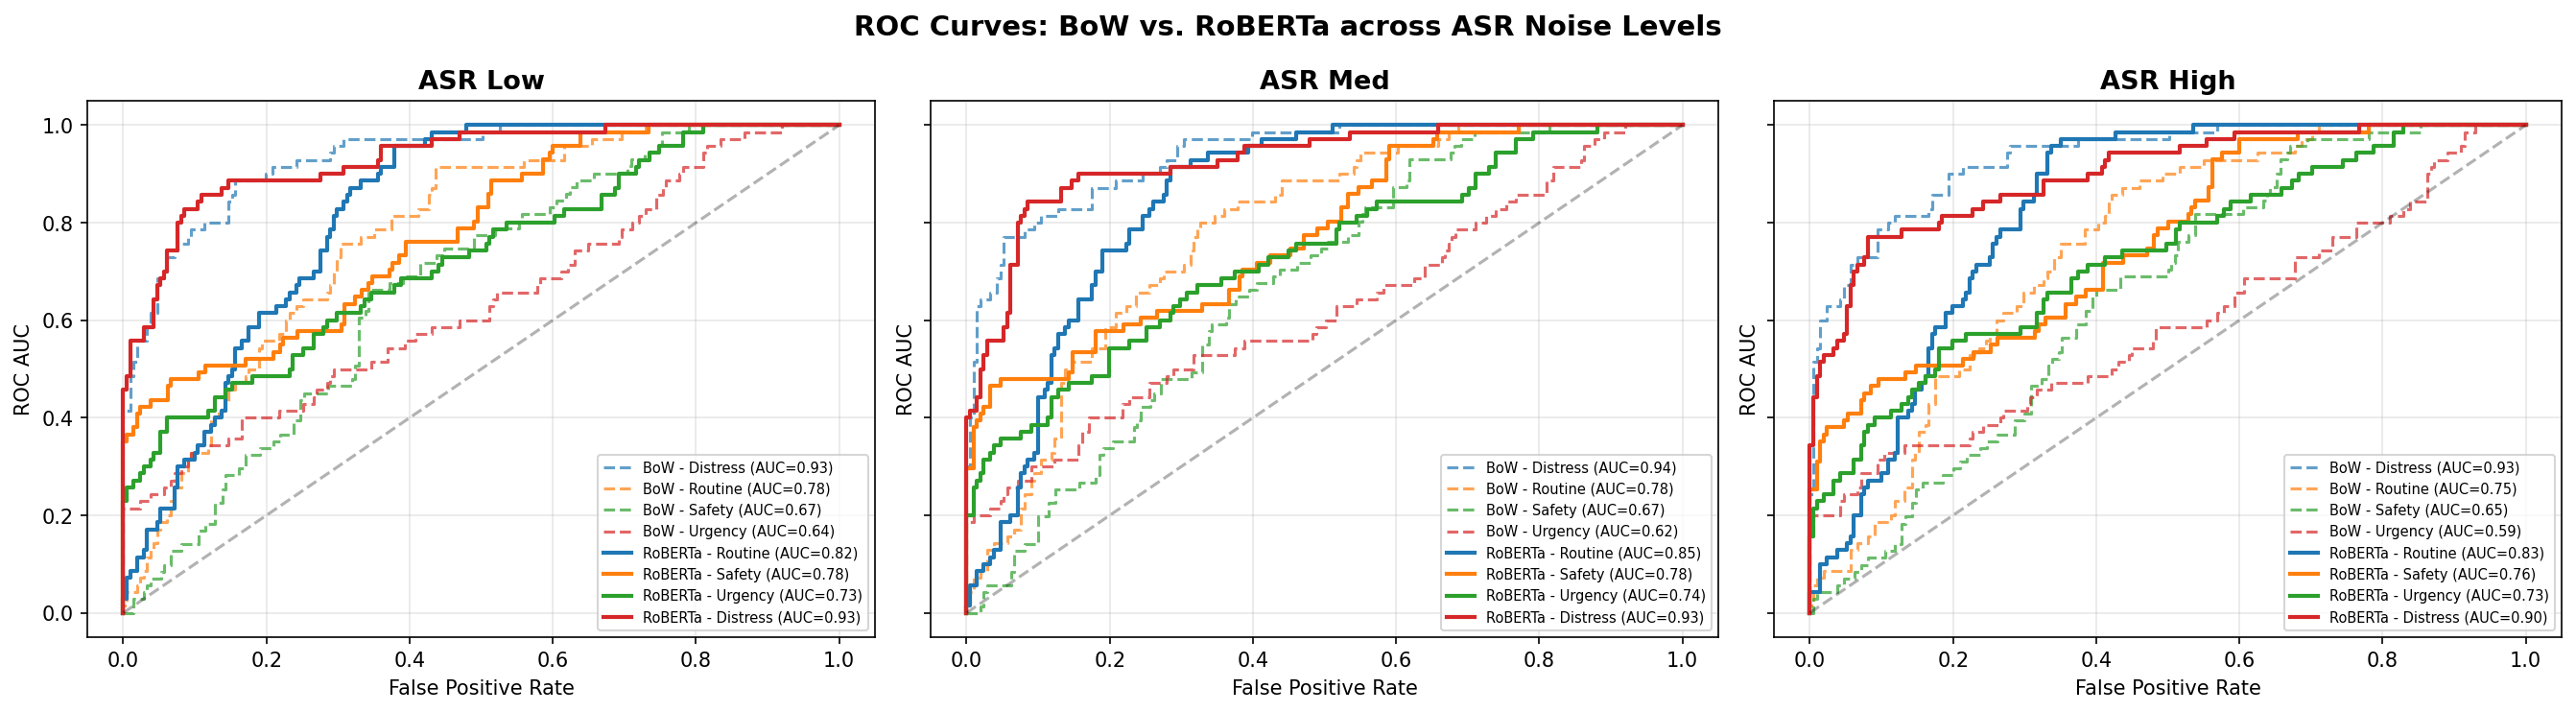


Saved to: /content/drive/MyDrive/SeaAlert/results/roc_curves_asr.png


In [8]:


matplotlib.rcParams['figure.dpi'] = 150

# Class names from label2id
classes     = sorted(label2id, key=label2id.get)
n_classes   = len(classes)
colors      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['ASR Low', 'ASR Med', 'ASR High']

for ax, col, title in zip(axes, asr_columns, titles):
    X_texts = df_asr[col].fillna("").values

    # BoW probabilities
    y_prob_bow  = bow_model.predict_proba(X_texts)
    y_true_bin  = label_binarize(y_true_text_asr, classes=bow_classes)

    # RoBERTa probabilities
    y_prob_rob, _ = get_roberta_predictions(X_texts)
    y_true_bin_rob = label_binarize(y_true_int_asr, classes=roberta_classes_order)

    for i, cls in enumerate(bow_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_bow[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], linestyle='--', alpha=0.7,
                label=f'BoW - {cls} (AUC={roc_auc:.2f})')

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin_rob[:, i], y_prob_rob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], linestyle='-', linewidth=2,
                label=f'RoBERTa - {cls} (AUC={roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('ROC AUC')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: BoW vs. RoBERTa across ASR Noise Levels', fontsize=14, fontweight='bold')
plt.tight_layout()

roc_path = f'{base_dir}/results/roc_curves_asr.png'
plt.savefig(roc_path, bbox_inches='tight')
plt.show()
print(f"\nSaved to: {roc_path}")

In [9]:
# ROC AUC Summary Table
roc_data = []

for col, title in zip(asr_columns, ['ASR_LOW', 'ASR_MED', 'ASR_HIGH']):
    X_texts    = df_asr[col].fillna("").values
    y_true_bin = label_binarize(y_true_text_asr, classes=bow_classes)
    y_prob_bow = bow_model.predict_proba(X_texts)

    y_prob_rob, _  = get_roberta_predictions(X_texts)
    y_true_bin_rob = label_binarize(y_true_int_asr, classes=roberta_classes_order)

    for i, cls in enumerate(bow_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_bow[:, i])
        roc_data.append({
            'Noise Level': title,
            'Model': 'Logistic Regression (BoW)',
            'Class': cls,
            'AUC': round(auc(fpr, tpr), 3)
        })

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin_rob[:, i], y_prob_rob[:, i])
        roc_data.append({
            'Noise Level': title,
            'Model': 'RoBERTa (Transformer)',
            'Class': cls,
            'AUC': round(auc(fpr, tpr), 3)
        })

df_roc = pd.DataFrame(roc_data)

print("\n" + "=" * 60)
print("ROC AUC PER CLASS: BoW vs. RoBERTa across ASR Noise Levels")
print("=" * 60 + "\n")
display(df_roc.pivot_table(index=['Noise Level', 'Class'], columns='Model', values='AUC'))

roc_table_path = f'{base_dir}/results/roc_auc_per_class.csv'
df_roc.to_csv(roc_table_path, index=False)
print(f"\nSaved to: {roc_table_path}")


ROC AUC PER CLASS: BoW vs. RoBERTa across ASR Noise Levels



Model                 Logistic Regression (BoW)  RoBERTa (Transformer)
Noise Level Class                                                     
ASR_HIGH    Distress                      0.932                  0.899
            Routine                       0.746                  0.826
            Safety                        0.649                  0.761
            Urgency                       0.587                  0.731
ASR_LOW     Distress                      0.934                  0.930
            Routine                       0.776                  0.823
            Safety                        0.673                  0.782
            Urgency                       0.636                  0.726
ASR_MED     Distress                      0.937                  0.926
            Routine                       0.782                  0.850
            Safety                        0.673                  0.778
            Urgency                       0.623                  0.735


Saved to: /content/drive/MyDrive/SeaAlert/results/roc_auc_per_class.csv
